# K-Nearest Neighbors


## Import Libraries


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


## Load Dataset


In [2]:
data = load_wine()
X = data.data
y = data.target


## Preprocessing


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Choosing a Suitable K


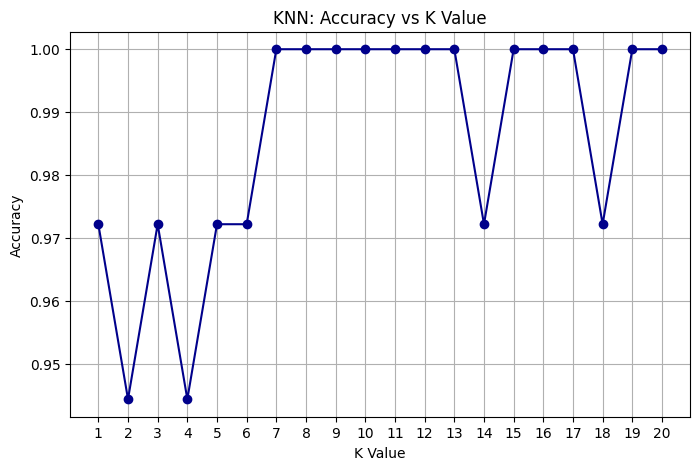

In [4]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(knn.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o", color="darkblue")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs K Value")
plt.xticks(k_values)
plt.grid(True)
plt.show()


## Model Training


In [5]:
optimal_k = list(k_values)[accuracies.index(max(accuracies))]
print(f"Selected K: {optimal_k}")
model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train, y_train)


Selected K: 7


## Prediction


In [6]:
y_pred = model.predict(X_test)


## Evaluation


In [7]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=data.target_names)
print(f"Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)


Accuracy: 1.0000

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Visualization


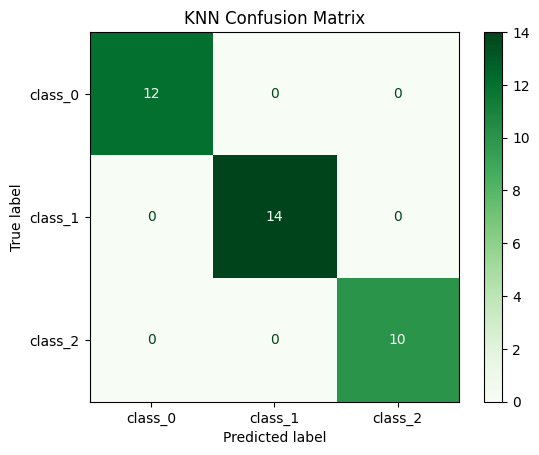

In [8]:
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=data.target_names)
display.plot(cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.show()
